In [5]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from pathlib import Path 
import os 
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)
df = pd.read_csv("AirQuality.csv", sep= ';' ) 

print("📊 RAW DATA (first 5 rows):")
print("="*60)
print(df.head().to_string())  # This will show all columns

print("\n📊 COLUMNS FOUND:")
print("="*60)
for i, col in enumerate(df.columns):
    print(f"{i}: {col}")

print(f"\nShape: {df.shape}")

📊 RAW DATA (first 5 rows):
         Date      Time CO(GT)  PT08.S1(CO)  NMHC(GT) C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)     T    RH      AH  Unnamed: 15  Unnamed: 16
0  10/03/2004  18.00.00    2,6       1360.0     150.0     11,9         1046.0    166.0        1056.0    113.0        1692.0       1268.0  13,6  48,9  0,7578          NaN          NaN
1  10/03/2004  19.00.00      2       1292.0     112.0      9,4          955.0    103.0        1174.0     92.0        1559.0        972.0  13,3  47,7  0,7255          NaN          NaN
2  10/03/2004  20.00.00    2,2       1402.0      88.0      9,0          939.0    131.0        1140.0    114.0        1555.0       1074.0  11,9  54,0  0,7502          NaN          NaN
3  10/03/2004  21.00.00    2,2       1376.0      80.0      9,2          948.0    172.0        1092.0    122.0        1584.0       1203.0  11,0  60,0  0,7867          NaN          NaN
4  10/03/2004  22.00.00    1,6       1272.0      51.0     

In [7]:
print("Sample date:", df.iloc[0, 0]) # first column, first row
print("Sample time:", df.iloc[0, 1])  # second column, first row

# Create datetime by combining first two columns
df['datetime'] = pd.to_datetime(
    df.iloc[:, 0] + ' ' + df.iloc[:, 1], 
    format='%d/%m/%Y %H.%M.%S',
    errors='coerce'
)
# Set as index
df = df.set_index('datetime')

# Drop the original date/time columns
df = df.drop(df.columns[[0, 1]], axis=1)

print("\n✅ Datetime index created")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Total rows: {len(df)}")

if df.index.isna().any():
    print(f"⚠️ Warning: {df.index.isna().sum()} rows have invalid datetime")
    df = df.dropna()


Sample date: 10/03/2004
Sample time: 18.00.00

✅ Datetime index created
Date range: 2004-03-10 18:00:00 to 2005-04-04 14:00:00
Total rows: 9471
⚠️ Warning: 114 rows have invalid datetime


In [8]:
invalid_datetime= df[df.index.isna()]
print("🔍 SAMPLE OF invalid DATES:")
print("="*60)
print(invalid_datetime.head(10))

print("\n📝 ORIGINAL DATA FOR BAD ROWS:")
print("="*60)
df_raw = pd.read_csv( "AirQuality.csv", sep= ';', header=None, nrows=120 ) 

print(df_raw.iloc[90:110])

🔍 SAMPLE OF invalid DATES:
Empty DataFrame
Columns: [CO(GT), PT08.S1(CO), NMHC(GT), C6H6(GT), PT08.S2(NMHC), NOx(GT), PT08.S3(NOx), NO2(GT), PT08.S4(NO2), PT08.S5(O3), T, RH, AH, Unnamed: 15, Unnamed: 16]
Index: []

📝 ORIGINAL DATA FOR BAD ROWS:
             0         1     2     3    4     5     6     7     8     9   \
90   14/03/2004  11.00.00   2,8  1445  148  10,9  1009   176   878   114   
91   14/03/2004  12.00.00   2,8  1416  145  10,7  1002   161   907   119   
92   14/03/2004  13.00.00     2  1281   93   7,5   880   113  1084   104   
93   14/03/2004  14.00.00   1,8  1207   84   7,5   879   103  1104   102   
94   14/03/2004  15.00.00   1,9  1258   99   8,2   906   112  1081   107   
95   14/03/2004  16.00.00     3  1458  150  11,9  1045   170   974   129   
96   14/03/2004  17.00.00   2,9  1438  156  12,0  1051   180   943   128   
97   14/03/2004  18.00.00   2,5  1478  122  12,2  1055   160   929   121   
98   14/03/2004  19.00.00   4,6  1808  262  20,6  1312   261   753   1

In [9]:
import pandas as pd
import numpy as np

df_raw= pd.read_csv("AirQuality.csv", sep= ';', header=None, nrows=120 ) 

# First, let's read just to see the structure


print("📊 RAW DATA SHAPE:", df_raw.shape)
print("\nFirst 3 rows:")
print(df_raw.head(3))
print("\nLast 3 rows:")
print(df_raw.tail(3))

column_names = df_raw.iloc[0].tolist()
print("\n📋 Column names found:", column_names)

df = pd.read_csv("AirQuality.csv", sep= ';', header=0 ) 
df = df.dropna(axis=1, how='all')

print(f"\n✅ After cleaning: {df.shape[1]} columns remain")
print(df.columns.tolist())


📊 RAW DATA SHAPE: (120, 17)

First 3 rows:
           0         1       2            3         4         5   \
0        Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)   
1  10/03/2004  18.00.00     2,6         1360       150      11,9   
2  10/03/2004  19.00.00       2         1292       112       9,4   

              6        7             8        9             10           11  \
0  PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)   
1           1046      166          1056      113          1692         1268   
2            955      103          1174       92          1559          972   

     12    13      14  15  16  
0     T    RH      AH NaN NaN  
1  13,6  48,9  0,7578 NaN NaN  
2  13,3  47,7  0,7255 NaN NaN  

Last 3 rows:
             0         1    2     3    4     5     6    7    8    9     10  \
117  15/03/2004  14.00.00  2,9  1400  191  15,4  1162  159  838  111  1829   
118  15/03/2004  15.00.00  2,5  1317  185  12,1  1053  153  926  104 

In [10]:
# Look at first few rows to understand structure
print("📊 FIRST 5 ROWS:")
print("="*60)
print(df.head().to_string())

# Combine date and time columns (they should be first two columns)
date_col = df.columns[0]  # first column
time_col = df.columns[1]  # second column

print(f"\nDate column: {date_col}")
print(f"Time column: {time_col}")

df['datetime'] = pd.to_datetime(
    df[date_col].astype(str) + ' ' + df[time_col].astype(str),
    format='%d/%m/%Y %H.%M.%S',
    errors='coerce'
)

# Drop rows with invalid datetime
before = len(df)
df = df.dropna(subset=['datetime'])
print(f"Dropped {before - len(df)} rows with invalid datetime")

# Set as index
df = df.set_index('datetime')

# Drop the original date/time columns
df = df.drop(columns=[date_col, time_col])

# Convert all remaining columns to numeric (replacing comma with dot)
for col in df.columns:
    if df[col].dtype == 'object':  # if it's text
        # Replace comma with dot and convert
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(',', '.').str.strip(),
            errors='coerce'
        )

print(f"\n✅ Final shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

📊 FIRST 5 ROWS:
         Date      Time CO(GT)  PT08.S1(CO)  NMHC(GT) C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)     T    RH      AH
0  10/03/2004  18.00.00    2,6       1360.0     150.0     11,9         1046.0    166.0        1056.0    113.0        1692.0       1268.0  13,6  48,9  0,7578
1  10/03/2004  19.00.00      2       1292.0     112.0      9,4          955.0    103.0        1174.0     92.0        1559.0        972.0  13,3  47,7  0,7255
2  10/03/2004  20.00.00    2,2       1402.0      88.0      9,0          939.0    131.0        1140.0    114.0        1555.0       1074.0  11,9  54,0  0,7502
3  10/03/2004  21.00.00    2,2       1376.0      80.0      9,2          948.0    172.0        1092.0    122.0        1584.0       1203.0  11,0  60,0  0,7867
4  10/03/2004  22.00.00    1,6       1272.0      51.0      6,5          836.0    131.0        1205.0    116.0        1490.0       1110.0  11,2  59,6  0,7888

Date column: Date
Time column: Time
Dropp

In [11]:
# CELL 6.5: Quick exploration of cleaned data

print("📊 FINAL DATASET INFO:")
print("="*60)
print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Total time span: {df.index.max() - df.index.min()}")
print(f"Number of columns: {len(df.columns)}")

print("\n📊 COLUMN STATISTICS:")
print("="*60)
stats = []
for col in df.columns:
    stats.append({
        'Column': col,
        'Type': df[col].dtype,
        'Non-null': df[col].count(),
        'Null %': (1 - df[col].count()/len(df))*100,
        'Mean': df[col].mean(),
        'Std': df[col].std()
    })

stats_df = pd.DataFrame(stats)
print(stats_df.to_string())

# Show first few rows of actual data
print("\n📊 FIRST 5 ROWS OF CLEANED DATA:")
print("="*60)
print(df.head().to_string())

# Show last few rows
print("\n📊 LAST 5 ROWS OF CLEANED DATA:")
print("="*60)
print(df.tail().to_string())

# Check for any remaining issues
print("\n🔍 QUICK QUALITY CHECK:")
print("="*60)
print(f"Any remaining nulls? {df.isnull().any().any()}")
print(f"Any infinite values? {np.isinf(df.select_dtypes(include=[np.number])).any().any()}")

📊 FINAL DATASET INFO:
Shape: (9357, 13)
Date range: 2004-03-10 18:00:00 to 2005-04-04 14:00:00
Total time span: 389 days 20:00:00
Number of columns: 13

📊 COLUMN STATISTICS:
           Column     Type  Non-null  Null %         Mean         Std
0          CO(GT)  float64      9357     0.0   -34.207524   77.657170
1     PT08.S1(CO)  float64      9357     0.0  1048.990061  329.832710
2        NMHC(GT)  float64      9357     0.0  -159.090093  139.789093
3        C6H6(GT)  float64      9357     0.0     1.865683   41.380206
4   PT08.S2(NMHC)  float64      9357     0.0   894.595276  342.333252
5         NOx(GT)  float64      9357     0.0   168.616971  257.433866
6    PT08.S3(NOx)  float64      9357     0.0   794.990168  321.993552
7         NO2(GT)  float64      9357     0.0    58.148873  126.940455
8    PT08.S4(NO2)  float64      9357     0.0  1391.479641  467.210125
9     PT08.S5(O3)  float64      9357     0.0   975.072032  456.938184
10              T  float64      9357     0.0     9.77830

📊 BEFORE CLEANING - Columns with negative values:
CO(GT)          | Negatives:   1683 (17.99%) | Min:  -200.00
PT08.S1(CO)     | Negatives:    366 ( 3.91%) | Min:  -200.00
NMHC(GT)        | Negatives:   8443 (90.23%) | Min:  -200.00
C6H6(GT)        | Negatives:    366 ( 3.91%) | Min:  -200.00
PT08.S2(NMHC)   | Negatives:    366 ( 3.91%) | Min:  -200.00
NOx(GT)         | Negatives:   1639 (17.52%) | Min:  -200.00
PT08.S3(NOx)    | Negatives:    366 ( 3.91%) | Min:  -200.00
NO2(GT)         | Negatives:   1642 (17.55%) | Min:  -200.00
PT08.S4(NO2)    | Negatives:    366 ( 3.91%) | Min:  -200.00
PT08.S5(O3)     | Negatives:    366 ( 3.91%) | Min:  -200.00
T               | Negatives:    379 ( 4.05%) | Min:  -200.00
RH              | Negatives:    366 ( 3.91%) | Min:  -200.00
AH              | Negatives:    366 ( 3.91%) | Min:  -200.00

📊 AFTER CLEANING - Check for any remaining negatives:
CO(GT)          | ✅ No negatives
PT08.S1(CO)     | ✅ No negatives
NMHC(GT)        | ✅ No negatives
C6H

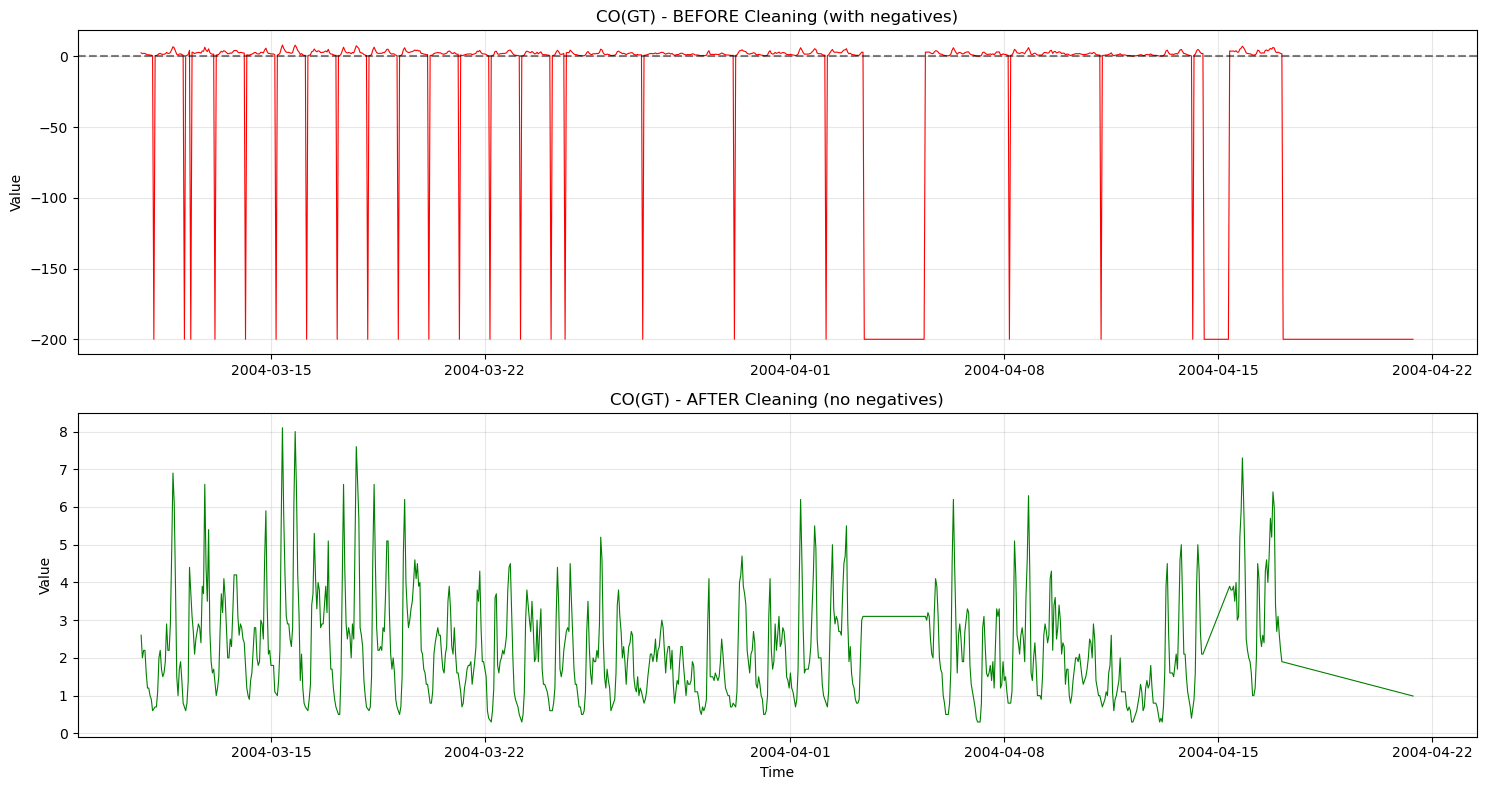


✅ Cleaned data shape: (9357, 13)


In [12]:
# CELL 7: Clean negative values (they don't make physical sense)

print("📊 BEFORE CLEANING - Columns with negative values:")
print("="*60)

# Check each column for negative values
for col in df.columns:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        neg_pct = (neg_count / len(df)) * 100
        min_val = df[col].min()
        print(f"{col:15} | Negatives: {neg_count:6} ({neg_pct:5.2f}%) | Min: {min_val:8.2f}")

# Create a cleaned version of the data
df_clean = df.copy()

# For each column, replace negative values with NaN
for col in df_clean.columns:
    df_clean.loc[df_clean[col] < 0, col] = np.nan

# Interpolate to fill NaN values
df_clean = df_clean.interpolate(method='linear', limit_direction='both')

print("\n📊 AFTER CLEANING - Check for any remaining negatives:")
print("="*60)
for col in df_clean.columns:
    neg_count = (df_clean[col] < 0).sum()
    if neg_count > 0:
        print(f"{col}: {neg_count} negatives remain")
    else:
        print(f"{col:15} | ✅ No negatives")

# Pick your target column (CO(GT) is typical for air quality)
target_col = 'CO(GT)'

# Plot before and after for your target
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

axes[0].plot(df.index[:1000], df[target_col].iloc[:1000], linewidth=0.8, color='red')
axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[0].set_title(f'{target_col} - BEFORE Cleaning (with negatives)')
axes[0].set_ylabel('Value')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_clean.index[:1000], df_clean[target_col].iloc[:1000], 
             linewidth=0.8, color='green')
axes[1].set_title(f'{target_col} - AFTER Cleaning (no negatives)')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Value')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Cleaned data shape: {df_clean.shape}")

In [13]:
# CELL 8: Create sliding windows for forecasting

def create_windows(data, target_col, window_size=24, horizon=1):
    """
    Create sliding windows for time series.
    
    Args:
        data: DataFrame with cleaned data
        target_col: column to predict
        window_size: 24 hours of history
        horizon: predict next hour
    
    Returns:
        X: input windows, y: targets
    """
    values = data[target_col].values
    X, y = [], []
    
    for i in range(len(values) - window_size - horizon + 1):
        # Input: last 24 hours
        X.append(values[i:i + window_size])
        # Target: next hour value
        y.append(values[i + window_size + horizon - 1])
    
    return np.array(X), np.array(y)

# Create windows
window_size = 24  # 24 hours of history
horizon = 1       # predict next hour

X, y = create_windows(df_clean, target_col, window_size, horizon)

print(f"✅ Windows created!")
print(f"X shape: {X.shape}  ({X.shape[0]} samples, {window_size} hours each)")
print(f"y shape: {y.shape}")
print(f"\nFirst window (24 hours):")
print(f"  Hours 0-23: [{X[0,0]:.2f}, {X[0,1]:.2f}, ..., {X[0,-1]:.2f}]")
print(f"Target (hour 24): {y[0]:.2f}")

✅ Windows created!
X shape: (9333, 24)  (9333 samples, 24 hours each)
y shape: (9333,)

First window (24 hours):
  Hours 0-23: [2.60, 2.00, ..., 2.90]
Target (hour 24): 4.80


📊 DATA SPLIT (chronological):
Total samples: 9333
Train: 6533 (70.0%) - earliest
Val:   1399 (15.0%) - middle
Test:  1401 (15.0%) - latest


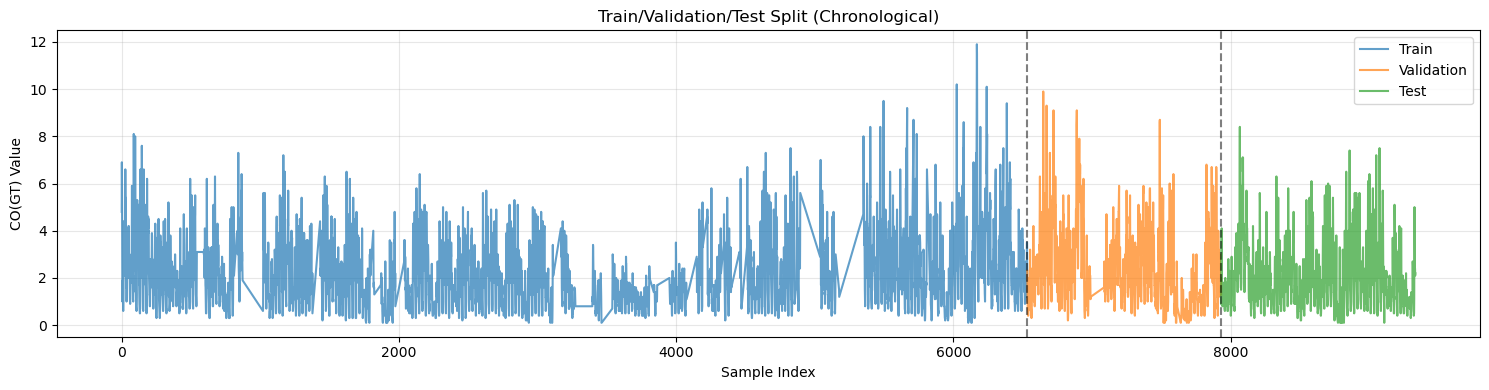


✅ Data saved to 'processed_data.npz'
✅ Metadata saved to 'metadata.json'


In [14]:
# CELL 9: Chronological split and save

# Split indices (NO SHUFFLING!)
n = len(X)
train_end = int(n * 0.7)
val_end = train_end + int(n * 0.15)

X_train = X[:train_end]
y_train = y[:train_end]

X_val = X[train_end:val_end]
y_val = y[train_end:val_end]

X_test = X[val_end:]
y_test = y[val_end:]

print("📊 DATA SPLIT (chronological):")
print("="*50)
print(f"Total samples: {n}")
print(f"Train: {len(X_train)} ({len(X_train)/n*100:.1f}%) - earliest")
print(f"Val:   {len(X_val)} ({len(X_val)/n*100:.1f}%) - middle")
print(f"Test:  {len(X_test)} ({len(X_test)/n*100:.1f}%) - latest")

# Quick plot to verify split
plt.figure(figsize=(15, 4))
plt.plot(range(len(y_train)), y_train, label='Train', alpha=0.7)
plt.plot(range(len(y_train), len(y_train)+len(y_val)), y_val, label='Validation', alpha=0.7)
plt.plot(range(len(y_train)+len(y_val), len(y)), y_test, label='Test', alpha=0.7)
plt.axvline(x=len(y_train), color='black', linestyle='--', alpha=0.5)
plt.axvline(x=len(y_train)+len(y_val), color='black', linestyle='--', alpha=0.5)
plt.xlabel('Sample Index')
plt.ylabel(f'{target_col} Value')
plt.title('Train/Validation/Test Split (Chronological)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Save everything
np.savez('processed_data.npz',
         X_train=X_train, y_train=y_train,
         X_val=X_val, y_val=y_val,
         X_test=X_test, y_test=y_test)

print("\n✅ Data saved to 'processed_data.npz'")

# Also save metadata
metadata = {
    'target_col': target_col,
    'window_size': window_size,
    'horizon': horizon,
    'train_samples': len(X_train),
    'val_samples': len(X_val),
    'test_samples': len(X_test),
    'date_range': f"{df_clean.index[0]} to {df_clean.index[-1]}"
}

import json
with open('metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4, default=str)

print("✅ Metadata saved to 'metadata.json'")

In [15]:
# CELL 10: Extract clean data in multiple formats

import pandas as pd
import numpy as np
import json

# 1. Save as CSV (most portable)
df_clean.to_csv('air_quality_clean.csv')
print("✅ Saved as CSV: 'air_quality_clean.csv'")

# 2. Save as Excel (if you need)
df_clean.to_excel('air_quality_clean.xlsx')
print("✅ Saved as Excel: 'air_quality_clean.xlsx'")

# 3. Save just the target column (CO(GT)) as simple CSV
target_df = pd.DataFrame({
    'datetime': df_clean.index,
    'CO_GT': df_clean['CO(GT)'].values
})
target_df.to_csv('co_gt_timeseries.csv', index=False)
print("✅ Saved target column: 'co_gt_timeseries.csv'")

# 4. Save the windowed data (ready for ML)
np.savez('ml_ready_data.npz',
         X_train=X_train, y_train=y_train,
         X_val=X_val, y_val=y_val,
         X_test=X_test, y_test=y_test)
print("✅ Saved ML-ready data: 'ml_ready_data.npz'")

# 5. Create a small sample for quick viewing
sample_df = df_clean.head(1000).copy()
sample_df.to_csv('sample_1000_rows.csv')
print("✅ Saved sample (first 1000 rows): 'sample_1000_rows.csv'")

print("\n📊 DATA SUMMARY FOR YOUR SLIDES:")
print("="*60)
print(f"Total records: {len(df_clean)}")
print(f"Date range: {df_clean.index.min()} to {df_clean.index.max()}")
print(f"Time span: {df_clean.index.max() - df_clean.index.min()}")
print(f"Features: {len(df_clean.columns)}")
print(f"\nTarget column: CO(GT)")
print(f"  - Min: {df_clean['CO(GT)'].min():.2f}")
print(f"  - Max: {df_clean['CO(GT)'].max():.2f}")
print(f"  - Mean: {df_clean['CO(GT)'].mean():.2f}")
print(f"  - Std: {df_clean['CO(GT)'].std():.2f}")

✅ Saved as CSV: 'air_quality_clean.csv'
✅ Saved as Excel: 'air_quality_clean.xlsx'
✅ Saved target column: 'co_gt_timeseries.csv'
✅ Saved ML-ready data: 'ml_ready_data.npz'
✅ Saved sample (first 1000 rows): 'sample_1000_rows.csv'

📊 DATA SUMMARY FOR YOUR SLIDES:
Total records: 9357
Date range: 2004-03-10 18:00:00 to 2005-04-04 14:00:00
Time span: 389 days 20:00:00
Features: 13

Target column: CO(GT)
  - Min: 0.10
  - Max: 11.90
  - Mean: 2.13
  - Std: 1.43


In [16]:
# CELL 15: Generate slide images

import matplotlib.pyplot as plt
import numpy as np

print("🖼️ Generating slide images...")
print("="*60)

# Slide 1: Data Overview
plt.figure(figsize=(15, 5))
plt.plot(df_clean.index, df_clean['CO(GT)'], linewidth=0.5, color='blue')
plt.title('Air Quality Dataset: CO(GT) Measurements\nMarch 2004 - April 2005', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('CO(GT) Concentration')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('slide1_data_overview.png', dpi=150)
plt.close()
print("✅ Created: slide1_data_overview.png")

# Slide 2: Before/After Cleaning
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Before cleaning
axes[0].plot(df.index[:500], df['CO(GT)'].iloc[:500], 
             color='red', linewidth=1, label='Raw Data')
axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.5, label='Zero line')
axes[0].set_title('Before Cleaning\n(Negative values present)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Time Step (hours)')
axes[0].set_ylabel('CO(GT)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# After cleaning
axes[1].plot(df_clean.index[:500], df_clean['CO(GT)'].iloc[:500], 
             color='green', linewidth=1, label='Cleaned Data')
axes[1].set_title('After Cleaning\n(All values positive)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Time Step (hours)')
axes[1].set_ylabel('CO(GT)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('slide2_preprocessing.png', dpi=150)
plt.close()
print("✅ Created: slide2_preprocessing.png")

# Slide 3: Train/Val/Test Split
plt.figure(figsize=(15, 5))

# Create color-coded segments
train_color = '#2E86AB'  # blue
val_color = '#A23B72'     # purple
test_color = '#F18F01'    # orange

plt.plot(range(len(y_train)), y_train, color=train_color, 
         linewidth=0.8, label=f'Train ({len(y_train)} samples, 70%)')
plt.plot(range(len(y_train), len(y_train)+len(y_val)), y_val, 
         color=val_color, linewidth=0.8, label=f'Validation ({len(y_val)} samples, 15%)')
plt.plot(range(len(y_train)+len(y_val), len(y)), y_test, 
         color=test_color, linewidth=0.8, label=f'Test ({len(y_test)} samples, 15%)')

# Add vertical lines at split points
plt.axvline(x=len(y_train), color='black', linestyle='--', alpha=0.7, linewidth=1)
plt.axvline(x=len(y_train)+len(y_val), color='black', linestyle='--', alpha=0.7, linewidth=1)

# Add annotations
plt.text(len(y_train)/2, plt.ylim()[1]*0.9, 'TRAIN', 
         ha='center', fontsize=12, fontweight='bold', color=train_color)
plt.text(len(y_train) + len(y_val)/2, plt.ylim()[1]*0.9, 'VALIDATION', 
         ha='center', fontsize=12, fontweight='bold', color=val_color)
plt.text(len(y_train) + len(y_val) + len(y_test)/2, plt.ylim()[1]*0.9, 'TEST', 
         ha='center', fontsize=12, fontweight='bold', color=test_color)

plt.xlabel('Sample Index (chronological order)')
plt.ylabel('CO(GT) Value')
plt.title('Train/Validation/Test Split (70-15-15)', fontsize=14, fontweight='bold')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('slide3_split.png', dpi=150)
plt.close()
print("✅ Created: slide3_split.png")

# Verify files were created
import os
print("\n📋 CHECKING CREATED FILES:")
print("="*60)
slide_files = ['slide1_data_overview.png', 'slide2_preprocessing.png', 'slide3_split.png']
for f in slide_files:
    if os.path.exists(f):
        size = os.path.getsize(f) / 1024
        print(f"✅ {f:30} - OK! ({size:.1f} KB)")
    else:
        print(f"❌ {f:30} - MISSING!")

print("\n🎉 DONE! slide images are ready!")

🖼️ Generating slide images...
✅ Created: slide1_data_overview.png
✅ Created: slide2_preprocessing.png
✅ Created: slide3_split.png

📋 CHECKING CREATED FILES:
✅ slide1_data_overview.png       - OK! (215.9 KB)
✅ slide2_preprocessing.png       - OK! (154.2 KB)
✅ slide3_split.png               - OK! (267.7 KB)

🎉 DONE! slide images are ready!
